# Cairo Real Estate — Data Cleaning Notebook
**Author:** Marwan Ashraf  
**Last updated:** 5/19/2026 
**Purpose:** Exploratory cleaning notebook to identify what transformations are needed before building the final cleaner script.

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import yaml


In [35]:
with open('../config.yaml', 'r') as f:
    config = yaml.safe_load(f)

In [36]:
df = pd.read_csv(config['data_source']['file_paths']['raw_file'])
df.info()

C:\Users\marwa\AppData\Local\Temp\ipykernel_44120\2548498825.py:1: DtypeWarning: Columns (11,12,20,24,25,26,42,43) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(config['data_source']['file_paths']['raw_file'])


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76711 entries, 0 to 76710
Data columns (total 44 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   title                        76709 non-null  object 
 1   city                         76711 non-null  object 
 2   district                     76711 non-null  object 
 3   area                         70120 non-null  object 
 4   neighborhood                 40712 non-null  object 
 5   property_type                76711 non-null  object 
 6   sale_or_rent                 76711 non-null  object 
 7   price                        76520 non-null  object 
 8   seller_name                  76711 non-null  object 
 9   area (mÂ²)                   0 non-null      float64
 10  property_subtype             76520 non-null  object 
 11  bedrooms                     76520 non-null  object 
 12  bathrooms                    76520 non-null  object 
 13  purpose         

In [37]:
null_titles = df[df['title'].isnull()]


In [38]:
pd.set_option('display.max_columns', None)

In [39]:
null_titles.head()

,title,city,district,area,neighborhood,property_type,sale_or_rent,price,seller_name,area (mÂ²),property_subtype,bedrooms,bathrooms,purpose,ownership,level,payment option,furnished,completion status,delivery term,delivery date,monthly installments,payment period (years),price type,deposit,insurance,rental frequency,electricity meter,water meter,covered parking,natural gas,security,pets allowed,balcony,private garden,pool,landline,maids room,built in kitchen appliances,elevator,central a/c & heating,listing_date,area (m²),compound
63142,NaN,Cairo,Mostakbal City,Aliva mostakbal city,NaN,villas,sale,"EGP 23,000,000",This ad is no longer available,NaN,iVilla,4,4,for sale,NaN,NaN,installment,NaN,ready,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,True,True,True,True,True,False,True,True,True,False,True,False,False,4/27/2026,310,NaN
66992,NaN,Cairo,Katameya,West Golf Compound,NaN,villas,sale,"EGP 75,000,000",Kemet Real Estate,NaN,Stand Alone Villa,10+,10+,for sale,resale,NaN,cash,yes,ready,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False,False,False,False,False,False,False,False,False,False,False,4/30/2026,"2,500",NaN


In [40]:
price_type = df['price type'].value_counts()
price_type

price type
negotiable    1229
Name: count, dtype: int64

## 1. Drop Irrelevant Columns

In [41]:
df.drop(columns = ['compound','area (mÂ²)','monthly installments', 'payment period (years)', 'price type'],inplace= True)

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76711 entries, 0 to 76710
Data columns (total 39 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   title                        76709 non-null  object
 1   city                         76711 non-null  object
 2   district                     76711 non-null  object
 3   area                         70120 non-null  object
 4   neighborhood                 40712 non-null  object
 5   property_type                76711 non-null  object
 6   sale_or_rent                 76711 non-null  object
 7   price                        76520 non-null  object
 8   seller_name                  76711 non-null  object
 9   property_subtype             76520 non-null  object
 10  bedrooms                     76520 non-null  object
 11  bathrooms                    76520 non-null  object
 12  purpose                      76520 non-null  object
 13  ownership                    48

## 2. Fix Data Types

In [43]:
additional_features_cols = config['data_source']['realstate_website']['features_list']
df[additional_features_cols] = df[additional_features_cols].astype(bool)

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76711 entries, 0 to 76710
Data columns (total 39 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   title                        76709 non-null  object
 1   city                         76711 non-null  object
 2   district                     76711 non-null  object
 3   area                         70120 non-null  object
 4   neighborhood                 40712 non-null  object
 5   property_type                76711 non-null  object
 6   sale_or_rent                 76711 non-null  object
 7   price                        76520 non-null  object
 8   seller_name                  76711 non-null  object
 9   property_subtype             76520 non-null  object
 10  bedrooms                     76520 non-null  object
 11  bathrooms                    76520 non-null  object
 12  purpose                      76520 non-null  object
 13  ownership                    48

In [45]:
df['listing_date'] = pd.to_datetime(df['listing_date'], errors='coerce')
# df.info()

In [46]:
df['price'] = df['price'].str.replace(',', '').str.replace('EGP', '').replace('nan',pd.NA).astype('Int64')




In [25]:
df['delivery date'].value_counts()

delivery date
2027               449
2026               214
2028               156
2029                93
2029.0              45
soon                23
2030                19
within 6 months     13
2027.0               8
2025                 7
2028.0               4
2030.0               4
2026.0               3
7.0                  2
7                    2
14                   1
13                   1
Name: count, dtype: int64

In [47]:
# Since delivery date has incossistent values we will keep it as a string for now 
df['delivery date'] = df['delivery date'].astype(str)

In [11]:
print(df['area (m²)'].describe())

count     70344.0
unique     1206.0
top         160.0
freq       1142.0
Name: area (m²), dtype: float64


In [48]:
import pandas as pd

# Show every row in the DataFrame
pd.set_option('display.max_rows', None)

# Show every column in the DataFrame
pd.set_option('display.max_columns', None)

# Show the full content within each cell (preventing long text from being cut off)
pd.set_option('display.max_colwidth', None)

# Show all items in a list inside a cell
pd.set_option('display.max_seq_items', None)


In [49]:
def clean_area(col: pd.Series) -> pd.Series:
    """
    Cleans a messy area column with:
    - Comma thousand separators (1,000 → 1000)
    - Float strings (207.0 → 207)
    - Legitimate decimals (163.5 stays)
    - NaN passthrough
    """
    return (
        col.astype(str)
           .str.replace(',', '', regex=False)   # remove thousand separators
           .replace('nan', pd.NA)
           .pipe(pd.to_numeric, errors='coerce') # coerce anything unparseable → NaN
    )


In [50]:
df['area (m²)'] = clean_area(df['area (m²)'])
# df.info()

In [51]:
object_cols = df.select_dtypes(include='object').columns
for col in object_cols:
    df[col] = df[col].convert_dtypes()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76711 entries, 0 to 76710
Data columns (total 39 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   title                        76709 non-null  string        
 1   city                         76711 non-null  string        
 2   district                     76711 non-null  string        
 3   area                         70120 non-null  string        
 4   neighborhood                 40712 non-null  string        
 5   property_type                76711 non-null  string        
 6   sale_or_rent                 76711 non-null  string        
 7   price                        76520 non-null  Int64         
 8   seller_name                  76711 non-null  string        
 9   property_subtype             76520 non-null  string        
 10  bedrooms                     76520 non-null  object        
 11  bathrooms                    76520 non-nu

In [54]:
df['bedrooms'] = df['bedrooms'].convert_dtypes()
df['bathrooms'] = df['bathrooms'].convert_dtypes()

In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76711 entries, 0 to 76710
Data columns (total 39 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   title                        76709 non-null  string        
 1   city                         76711 non-null  string        
 2   district                     76711 non-null  string        
 3   area                         70120 non-null  string        
 4   neighborhood                 40712 non-null  string        
 5   property_type                76711 non-null  string        
 6   sale_or_rent                 76711 non-null  string        
 7   price                        76520 non-null  Int64         
 8   seller_name                  76711 non-null  string        
 9   property_subtype             76520 non-null  string        
 10  bedrooms                     76711 non-null  string        
 11  bathrooms                    76711 non-nu

## 3. Handle Missing Prices

In [56]:
# first thing I need to investigate the listings that has no price and see if they have any common featurs.
no_price_df = df[df['price'].isnull()]


In [57]:
no_price_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 191 entries, 1296 to 72573
Data columns (total 39 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   title                        191 non-null    string        
 1   city                         191 non-null    string        
 2   district                     191 non-null    string        
 3   area                         165 non-null    string        
 4   neighborhood                 87 non-null     string        
 5   property_type                191 non-null    string        
 6   sale_or_rent                 191 non-null    string        
 7   price                        0 non-null      Int64         
 8   seller_name                  191 non-null    string        
 9   property_subtype             0 non-null      string        
 10  bedrooms                     191 non-null    string        
 11  bathrooms                    191 non-null    

In [ ]:
no_price_df['district'].value_counts()

In [165]:
no_price_df['property_type'].value_counts()

property_type
apartments    137
villas         53
Name: count, dtype: int64

In [58]:
# Since all of them has no any meanigfull data I will drop them 
df.drop(no_price_df.index, inplace=True)


## 4. Impute: level → level_clean

In [59]:
# Now after addressing the data types I should deal with missing values.
# First column I will deal with is the level column 
df['level'].value_counts()

level
ground     1725
2          1494
3          1378
1          1296
4           939
5           540
6           179
7           100
10+          79
9            76
8            67
10           66
highest      41
Name: count, dtype: Int64

In [60]:
has_level = df[df['title'].str.contains('level', case=False, na=False) & df['level'].isnull()]
apartment_has_level = has_level[has_level['property_type'] == 'apartments']


In [61]:
# I cleared this output for the notebook to look clean
apartment_has_level['title'].unique()

<StringArray>
[                                                                                                                                                                                                             'For sale in Hyde Park Compound, an apartment with immediate occupancy, top-level finishing, overlooking the largest landscaped area,at the old contrat',
                                                                                                                                                                                                                            'A premium corner penthouse for sale in Mountain View Hyde Park, offering spacious interiors, a private roof, and a high level of privacy',
                                                                                                                                                                                                                       'Apartment for sale – Al Andalus 2   Location: Al A

In [62]:
titles_has_floor = df[df['title'].str.contains('floor', case=False, na=False) & df['level'].isnull() ]
titles_has_floor['title'].info()

<class 'pandas.core.series.Series'>
Index: 3313 entries, 37 to 76670
Series name: title
Non-Null Count  Dtype 
--------------  ----- 
3313 non-null   string
dtypes: string(1)
memory usage: 51.8 KB


In [ ]:
titles_has_floor.head(3)

,title,city,district,area,neighborhood,property_type,sale_or_rent,price,seller_name,property_subtype,bedrooms,bathrooms,purpose,ownership,level,payment option,furnished,completion status,delivery term,delivery date,monthly installments,payment period (years),price type,deposit,insurance,rental frequency,electricity meter,water meter,covered parking,natural gas,security,pets allowed,balcony,private garden,pool,landline,maids room,built in kitchen appliances,elevator,central a/c & heating,listing_date,area (m²)
37,"Ground floor apartment with garden for sale in Hyde Park, Fifth Settlement, New Cairo, at a price lower than market value.",Cairo,New Cairo,5th Settlement,Hyde Park New Cairo Compound,apartments,sale,5800000,4 C,Apartment,1,2,for sale,resale,<NA>,cash,no,ready,<NA>,nan,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,False,False,False,False,False,False,False,False,False,False,False,False,False,False,2026-04-21,95.0
103,"Ground floor apartment with garden for resale in Hyde Park, New Cairo - Grand Park",Cairo,New Cairo,5th Settlement,Hyde Park New Cairo Compound,apartments,sale,6100000,mohamed adel,Apartment,1,1,for sale,resale,<NA>,installment,no,off-plan,<NA>,nan,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,True,True,True,True,False,True,False,False,False,True,False,True,False,False,2026-04-21,75.0
112,Apartment 130m 3bd Ground Floor Fully Finished with Furniture Ready to Move in Hyde Park New Cairo,Cairo,New Cairo,5th Settlement,Hyde Park New Cairo Compound,apartments,sale,9500000,Middlemen,Apartment,3,2,for sale,resale,<NA>,cash,no,ready,<NA>,nan,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,True,True,True,False,True,True,False,False,False,False,False,False,False,False,2026-04-21,130.0


In [63]:
import re
list_of_levels = []
for title_has_level in titles_has_floor['title']:
    pattern = r'(\w+\s+floor\s+\w+)'
    match = re.search(pattern, title_has_level, re.IGNORECASE)
    if match:
        list_of_levels.append(match.group(1))
        # print(match.group(1))
    else:
        continue
       
print(len(list_of_levels))

2160


In [64]:
import re

def extract_floor_info(text):
    """
    Extract floor-related phrases like:
    - ground floor
    - first floor
    - second floor
    - 2nd floor
    - floor 3
    - 5th floor
    - roof floor
    - two-floor apartment

    while avoiding useless trailing words like:
    apartment, with, has, for, etc.
    """

    text = text.lower()

    patterns = [
        # # ground floor / first floor / second floor
        r'\b(1|2|3|4|5|6|basement|10th|upper|high|last|recurring|top|afirst|garden|ground|repetitive|repeated|rep|first|second|third|fourth|fifth|sixth|seventh|eighth|ninth|tenth|eleventh|twelfth)\s+floor(?:s)?\b',

        # 2nd floor / 5th floor / 10th floor
        r'\b\d+(?:st|nd|rd|th)\s+floor\b',

        # floor 2 / floor 3
        r'\bfloor\s+\d+\b',

        # roof floor
        r'\broof\s+floor\b',

        # typical floor
        r'\btypical\s+floor\b',

        # two-floor apartment / duplex hint
        r'\b(?:one|two|three|\d+)[-\s]?floor\b',

        r'(\w+)-floor', 
        r'floor:\s*[^a-zA-Z\d]*(\S+)',
       r'\b(\w+)\s+floors\s'
    ]

    for pattern in patterns:
        match = re.search(pattern, text, re.IGNORECASE)
        if match:
            return match.group()

    return None

In [65]:
list_of_levels = []
list_of_not_caputred = []
for row in titles_has_floor.iterrows():
    x = row[1]['title']
    match = extract_floor_info(x)
  
    if match:
            list_of_levels.append(match)
            # print(match)
    elif 'groundfloor' in x.lower():
        list_of_levels.append('ground floor')
    elif row[1]['property_subtype'] != 'Roof' or row[1]['property_subtype'] != 'Penthouse':
         list_of_not_caputred.append(row[1]['title'])
         
    elif row[1]['private garden'] == False and row[1]['property_type'] == 'apartments':
        list_of_not_caputred.append(row[1]['title'])
        list_of_levels.pop()
        print(f"No match found in subtype: {row[1]['property_subtype']} title: {row[1]['title']} with type {row[1]['property_type']}  ")
  
        # print(f"Title contains 'groundfloor': {x}")
    elif 'garden' in x.lower() and row[1]['property_type'] == 'apartments' and 'ground' not in x.lower() and 'view' not in x.lower():
         print(f"Title contains 'garden', skipping: {x}")

print(len(list_of_levels))
print(len(list_of_not_caputred))

3247
66


In [66]:
unique_set_levels = set(list_of_levels)
print(unique_set_levels)
print(len(unique_set_levels))

{'repetitive floor', 'floor:** gro', 'typical floor', 'two floors ', 'floor: 8th', 'parquet floors ', 'full-floor', '5th floor', '2  floor', '10th floor', 'high floors', 'basement floor', '2nd floor', 'fourth floor', 'floor: 3', 'ground-floor', '17th floor', 'floor: 8', 'floor  4', 'floor:** first', 'floor: second', 'repeated floor', 'heated floors ', 'floor 2', 'floor: fourth', 'floor: repeated', 'floor: first', 'floor 11', '4th floor', '2floor', 'floor 249', 'floor 1', '3 floors', 'ground floor', 'floor: 3rd', 'floor 155', 'two floor', 'floor 10', 'sixth floor', 'floor: third', 'high-floor', 'floor 3', 'garden floor', 'three floor', 'first-floor', 'third-floor', 'upper floor', 'tenth floor', 'floor 211', 'floor: 1st.', '2 floors', 'fifth floor', 'floor: rooftop', '3-floor', 'second floor', 'one floor', 'divided floors ', 'floor: ground', 'high floor', '3 floor', 'recurring floor', 'last floor', 'floor:** second', '8th floor', 'floor 5', 'second floors', 'floor: 10th,', 'top floor', '

In [67]:
df['property_type'].value_counts()

property_type
apartments    55213
villas        21307
Name: count, dtype: Int64

In [68]:
df['property_subtype'].value_counts()

property_subtype
Apartment            48858
Stand Alone Villa    12965
Town House            4364
Duplex                2755
Twin House            2570
Penthouse             1874
iVilla                1408
Studio                1026
Hotel Apartment        593
Room                    63
Roof                    44
Name: count, dtype: Int64

In [69]:
def impute_level(row):
    if pd.isna(row['imputed_level']):
        if row['property_type'] == 'apartments':
            if row['property_subtype'] == 'Penthouse':
                return 'top floor'
            if row['property_subtype'] == 'Roof':
                return 'roof'
            
        elif row['property_type'] == 'villas':
            return 'Independent Unit'
    return None

In [70]:
df['imputed_level'] = df['level']
for index, row in df.iterrows():

    if pd.isna(row['imputed_level']):

        imputed_value = impute_level(row)

        if imputed_value is not None:
            # print(f"Imputed level for index with property_type {row['property_type']}: {imputed_value}")
            df.loc[index, 'imputed_level'] = imputed_value
        elif 'floor' in row['title'].lower():
            match = extract_floor_info(row['title'])
            if match:
                df.loc[index, 'imputed_level'] = match


In [71]:
contains_level = df[df['title'].str.contains('level', case=False, na=False) & df['level'].isnull()]

In [72]:
contains_level.info()

<class 'pandas.core.frame.DataFrame'>
Index: 55 entries, 232 to 76497
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   title                        55 non-null     string        
 1   city                         55 non-null     string        
 2   district                     55 non-null     string        
 3   area                         43 non-null     string        
 4   neighborhood                 21 non-null     string        
 5   property_type                55 non-null     string        
 6   sale_or_rent                 55 non-null     string        
 7   price                        55 non-null     Int64         
 8   seller_name                  55 non-null     string        
 9   property_subtype             55 non-null     string        
 10  bedrooms                     55 non-null     string        
 11  bathrooms                    55 non-null     st

In [73]:
null_imputed_level = contains_level[contains_level['imputed_level'].isnull()]

In [ ]:
null_imputed_level.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16 entries, 13365 to 49627
Data columns (total 43 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   title                        16 non-null     string 
 1   city                         16 non-null     string 
 2   district                     16 non-null     string 
 3   area                         15 non-null     string 
 4   neighborhood                 2 non-null      string 
 5   property_type                16 non-null     string 
 6   sale_or_rent                 16 non-null     string 
 7   price                        16 non-null     Int64  
 8   seller_name                  16 non-null     string 
 9   property_subtype             16 non-null     string 
 10  bedrooms                     16 non-null     string 
 11  bathrooms                    16 non-null     string 
 12  purpose                      16 non-null     string 
 13  ownership           

In [74]:
for index, row in null_imputed_level.iterrows():
    if row['property_type'] != 'villas':
        print(f"Title contains 'level' but no imputed level for index {index} with title: {row['title']} and property type: {row['property_type']}")

Title contains 'level' but no imputed level for index 232 with title: For sale in Hyde Park Compound, an apartment with immediate occupancy, top-level finishing, overlooking the largest landscaped area,at the old contrat and property type: apartments
Title contains 'level' but no imputed level for index 6722 with title: A premium corner penthouse for sale in Mountain View Hyde Park, offering spacious interiors, a private roof, and a high level of privacy and property type: apartments
Title contains 'level' but no imputed level for index 13365 with title: 6 – Villas a premier apartment with direct View Garden, a very upscale location in the heart of Villas El-Nargis 6 – calm, privacy, and high-level housing. A strategic location near all axes and services: Diyar Al-Mukhabiirat Compound, Mohamed Naguib Axis, Gamal Abdel Nasser Axis, close to Al-Rehab Bridge, in front of Min and property type: apartments
Title contains 'level' but no imputed level for index 21567 with title: #Madinaty #مد

In [75]:
# This is the only listing that have level in the title that refering to the ground floor 
# All of the other listing that have leve in the title are taking about in sense of high quality items

df.loc[32481,['imputed_level']] = 'ground'

In [76]:
# there still nearly 30k listing that doesn't have any level information let's see how much in each property type 
null_imputed_level = df[df['imputed_level'].isnull()]

In [77]:
null_imputed_level.info()

<class 'pandas.core.frame.DataFrame'>
Index: 42377 entries, 0 to 75767
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   title                        42377 non-null  string        
 1   city                         42377 non-null  string        
 2   district                     42377 non-null  string        
 3   area                         39856 non-null  string        
 4   neighborhood                 23320 non-null  string        
 5   property_type                42377 non-null  string        
 6   sale_or_rent                 42377 non-null  string        
 7   price                        42377 non-null  Int64         
 8   seller_name                  42377 non-null  string        
 9   property_subtype             42377 non-null  string        
 10  bedrooms                     42377 non-null  string        
 11  bathrooms                    42377 non-null  s

In [98]:
null_imputed_level.describe(include='all')

,title,city,district,area,neighborhood,property_type,sale_or_rent,price,seller_name,property_subtype,bedrooms,bathrooms,purpose,ownership,level,payment option,furnished,completion status,delivery term,delivery date,monthly installments,payment period (years),price type,deposit,insurance,rental frequency,electricity meter,water meter,covered parking,natural gas,security,pets allowed,balcony,private garden,pool,landline,maids room,built in kitchen appliances,elevator,central a/c & heating,listing_date,area (m²),imputed_level
count,38708,38708,38708,36187,23320,38708,38708,38708.0,38708,38708,38708,38708,38708,24396,0,29814,32264,29816,2042,38708,1,1.0,343,1569,1526,7447,38708,38708,38708,38708,38708,38708,38708,38708,38708,38708,38708,38708,38708,38708,38708,38708.000000,0
unique,33139,1,36,239,111,1,2,<NA>,656,5,16,15,2,2,0,3,2,2,4,8,1,NaN,1,141,141,3,2,2,2,2,2,2,2,2,2,2,2,2,2,2,NaN,NaN,0
top,apartment for sale in Elpatio Oro new cairo ready to move under market price prime location,Cairo,New Cairo,5th Settlement,Mountain View iCity Compound,apartments,sale,<NA>,This ad is no longer available,Apartment,3.0,2.0,for sale,resale,NaN,cash,no,ready,finished,nan,"12,000",NaN,negotiable,"25,000","25,000",monthly,True,True,True,True,False,False,False,False,False,False,False,False,False,False,NaN,NaN,NaN
freq,35,38708,23071,19245,1614,38708,29816,<NA>,7401,35174,13636,10599,29816,12642,NaN,16980,25685,22268,1281,38525,1,NaN,343,130,97,7293,23794,21948,21259,22108,21119,19933,23813,21848,25972,20233,35532,25424,37131,33406,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7114592.150072,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-04-14 04:07:25.675312640,163.233776,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,950.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-04-29 00:00:00,15.000000,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3000000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-04-09 00:00:00,130.000000,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6500000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-04-16 00:00:00,160.000000,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10000000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-04-24 00:00:00,190.000000,NaN
max,NaN,NaN,NaN,NaN,NaN,NaN,NaN,225500000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-05-03 00:00:00,820.000000,NaN


In [78]:
null_imputed_level['property_type'].value_counts()

property_type
apartments    42377
Name: count, dtype: Int64

In [79]:
garden_in_title = null_imputed_level[null_imputed_level['title'].str.contains('with garden', case=False, na=False)]


In [33]:
null_imputed_level['property_subtype'].value_counts()

property_subtype
Apartment          35175
Duplex              2279
Studio               746
Hotel Apartment      452
Room                  56
Name: count, dtype: int64

In [ ]:
garden_in_title.info()

In [160]:
garden_in_title.head()

,title,city,district,area,neighborhood,property_type,sale_or_rent,price,seller_name,property_subtype,bedrooms,bathrooms,purpose,ownership,level,payment option,furnished,completion status,delivery term,delivery date,monthly installments,payment period (years),price type,deposit,insurance,rental frequency,electricity meter,water meter,covered parking,natural gas,security,pets allowed,balcony,private garden,pool,landline,maids room,built in kitchen appliances,elevator,central a/c & heating,listing_date,area (m²),imputed_level
36,Fully finished Apartment with garden 36m ready to move lowest price in compound hyde park new cairo fifth settlement,Cairo,New Cairo,5th Settlement,Hyde Park New Cairo Compound,apartments,sale,7880000,4 C,Apartment,2,2,for sale,resale,<NA>,installment,no,ready,<NA>,nan,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,False,False,False,False,False,False,False,False,False,False,False,False,False,False,4/21/2026,100.0,<NA>
38,Fully finished duplex with garden for sale 200 m and a garden 50 m 3 bedrooms prime location direct landscape view in Hyde Park New Cairo,Cairo,New Cairo,5th Settlement,Hyde Park New Cairo Compound,apartments,sale,16000000,4 C,Duplex,3,3,for sale,resale,<NA>,cash,no,ready,<NA>,nan,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,False,False,False,False,False,False,False,False,False,False,False,False,False,False,4/21/2026,200.0,<NA>
107,"Duplex with Garden Ready to Move In Landscape View Hyde Park, Garden Residence",Cairo,New Cairo,5th Settlement,Hyde Park New Cairo Compound,apartments,sale,9920000,4 C,Duplex,2,3,for sale,resale,<NA>,installment,<NA>,ready,<NA>,nan,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,False,False,False,False,False,False,False,False,False,False,False,False,False,False,4/21/2026,177.0,<NA>
172,Duplex 244m with Garden 133m Ready to Move Prime Location View Landscape in Hyde Park New Cairo,Cairo,New Cairo,5th Settlement,Hyde Park New Cairo Compound,apartments,sale,16500000,Middlemen,Duplex,3,4,for sale,resale,<NA>,cash,no,ready,<NA>,nan,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,True,True,True,False,True,True,False,False,False,False,False,False,False,False,4/21/2026,244.0,<NA>
279,prime location apartment with garden facing north in hyde park,Cairo,New Cairo,5th Settlement,Hyde Park New Cairo Compound,apartments,sale,12500000,Insider,Apartment,3,3,for sale,resale,<NA>,cash,no,ready,<NA>,nan,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,False,False,False,True,False,False,False,False,False,True,False,False,False,False,4/14/2026,186.0,<NA>


In [80]:
for index, row in garden_in_title.iterrows():
     df.loc[index, 'private garden'] = True
     level = impute_level(df.iloc[index])
     if level is not None:
          df.loc[index, 'imputed_level'] = level
    

In [81]:
import re

def standardize_level(val):
    if pd.isna(val):
        return None
    
    val = str(val).lower().strip()
    
    # Ground
    if any(x in val for x in ['ground', 'garden floor', 'floor:** gro']):
        return 'ground'
    
    # Top/Roof
    if any(x in val for x in ['roof', 'top', 'last', 'highest', 'high','99']):
        return 'top'
    
    # Recurring
    if any(x in val for x in ['recurring', 'repeated', 'repetitive', 'typical', 'full']):
        return 'recurring'
    
    # Basement
    if 'basement' in val:
        return 'basement'
    # This handle an edge case where it taking about the apartment floor not the level.
    if 'hdf' in val:
        return None 
    # Word-to-number mapping
    word_map = {
        'one': 1, 'first': 1, 'afirst': 1,
        'two': 2, 'second': 2,
        'three': 3, 'third': 3,
        'four': 4, 'fourth': 4,
        'five': 5, 'fifth': 5,
        'six': 6, 'sixth': 6,
        'seven': 7, 'seventh': 7,
        'eight': 8, 'eighth': 8,
        'nine': 9, 'ninth': 9,
        'ten': 10, 'tenth': 10,
        'eleven': 11, 'eleventh': 11,
        'top': 99, 
         'floor:** se' : 2# vague but low-ish
    }
    
    for word, num in word_map.items():
        if word in val:
            return num
    
    # Extract any number
    match = re.search(r'\d+', val)
    if match:
        num = int(match.group())
        if num > 50:  # clearly dirty like 249, 90
            return 'top'
        return num
    
    return val  



In [82]:
def standarize_arabic_level(match):
    if pd.isna(match):
        return None
    if 'متكرر' in match:
        return 'recuring'
    if any(x in match for x in ['الأرضي', 'ارضي', 'الارضى']):
        return 'ground'
    word_map  = {
       'دور أول': 1 , 'الدور الأول': 1 , 'دور اول': 1,'دور ثالث':3,
       'دور تاني': 2, 'دور تالت': 3 ,
       'دور ثانى': 2, 'دور تاني':2, 
       'الدور: الثالث': 3, 'دور تالت':3,
       'دور رابع':4,  'دور 4': 4,
       'الدور ١١': 11, 'بالدور 11قبل': 11, 'دور عاشر': 10,
       'دور حادى': 11, 
        }
    for word, val in word_map.items():
        if word in match:
            return val
    return pd.NA
    

In [83]:

df['level_clean'] = df['imputed_level'].apply(standardize_level)

In [84]:
arabic_pattern = r'[\u0600-\u06FF]'

# Boolean mask
arabic_mask = df['title'].str.contains(arabic_pattern, regex=True, na=False)

# Filter arabic titles
arabic_df = df[arabic_mask]


In [85]:
no_level_arabic_df = arabic_df[arabic_df['level_clean'].isnull()]

In [86]:
no_level_arabic_df = no_level_arabic_df[no_level_arabic_df['title'].str.contains('دور' , na = False)]

In [ ]:
# I removed the output to clean the notebook
no_level_arabic_df['title'].unique()

In [87]:
def extract_arabic_floor_info(title):
    patterns = [ 
      r'بالدور\s*:?\s*\S+',
        r'الدور\s*:?\s*\S+',
        r'دور\s+\S+'
    ]
    for pattern in patterns:
      match = re.search(pattern, title, re.IGNORECASE)
      if match is not None:
         return match.group()
    return None


In [88]:
flor = []
count = 0
for index, row in no_level_arabic_df.iterrows():
    count +=1
    matches = extract_arabic_floor_info(row['title'])
    if matches:
        flor.append({'index':index, 'match':matches})
print(count)


43


In [89]:
for item in flor:
    item['match'] = standarize_arabic_level(item['match'])

In [90]:
for item in flor:
    df.loc[item['index'], 'level_clean'] = item['match']

In [91]:
df['level_clean'] = df['level_clean'].convert_dtypes()

In [92]:
apartmens_df = df[df['property_type'] == 'apartments']
data = apartmens_df.groupby('district')['level_clean'].value_counts(normalize=True)

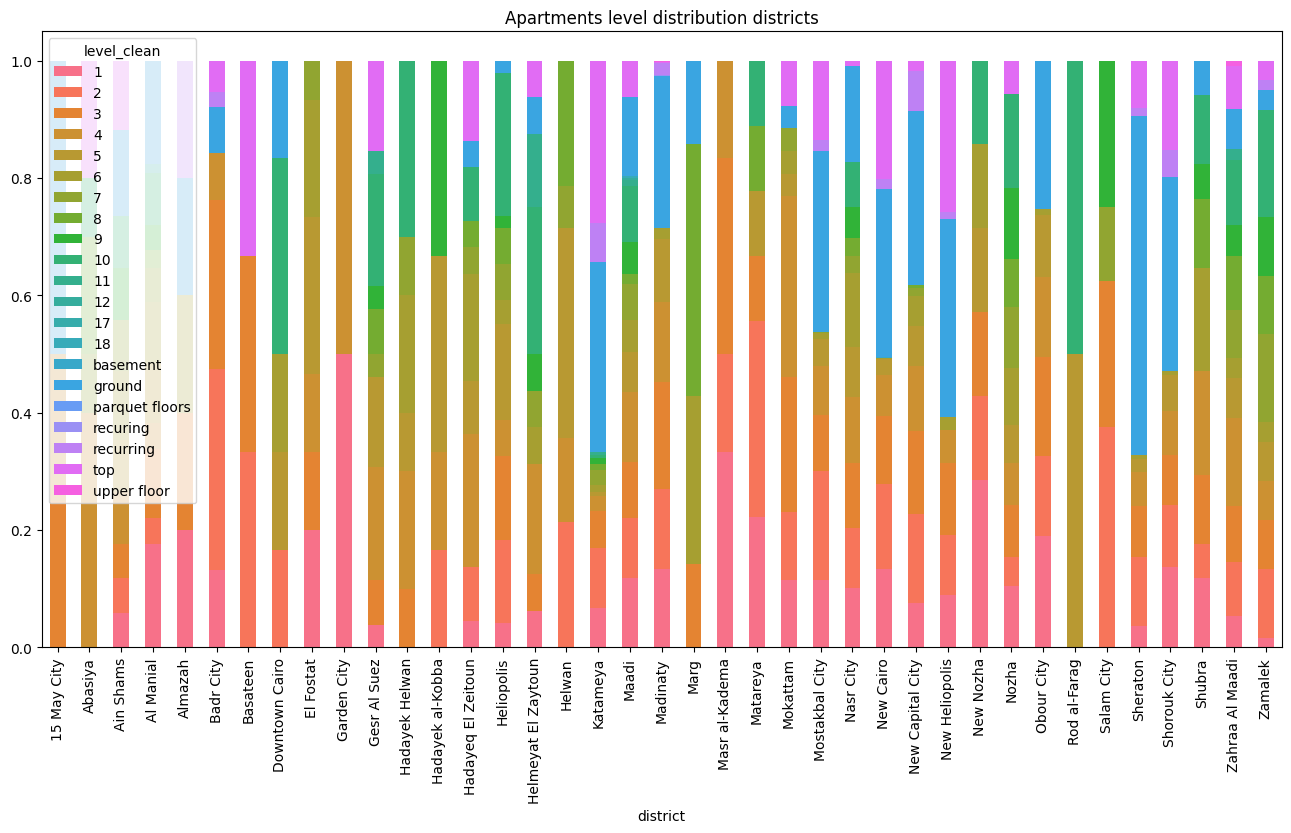

In [93]:
# Use a colormap with 25 distinct colors
import seaborn as sns
colors = sns.color_palette("husl", 23)
plot_df = data.unstack(level='level_clean').fillna(0)
plot_df = plot_df.loc[(plot_df !=0 ).any(axis=1), (plot_df !=0).any(axis=0)]
plot_df.plot(kind='bar', stacked=True, figsize=(16,8), color = colors)
# plt.tight_layout()
plt.title('Apartments level distribution districts')
plt.show()

In [149]:
df['level_clean'] = df['level_clean'].convert_dtypes()

In [94]:
df = df.drop(columns=['level', 'imputed_level'])

In [53]:
df.to_csv(config['data_source']['file_paths']['semi_cleaned_file'])

In [6]:
df = pd.read_csv(config['data_source']['file_paths']['semi_cleaned_file'])

C:\Users\marwa\AppData\Local\Temp\ipykernel_27136\1889476901.py:1: DtypeWarning: Columns (11,12,15,20,24,25,26,44) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(config['data_source']['file_paths']['semi_cleaned_file'])


In [95]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 76520 entries, 0 to 76710
Data columns (total 39 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   title                        76518 non-null  string        
 1   city                         76520 non-null  string        
 2   district                     76520 non-null  string        
 3   area                         69955 non-null  string        
 4   neighborhood                 40625 non-null  string        
 5   property_type                76520 non-null  string        
 6   sale_or_rent                 76520 non-null  string        
 7   price                        76520 non-null  Int64         
 8   seller_name                  76520 non-null  string        
 9   property_subtype             76520 non-null  string        
 10  bedrooms                     76520 non-null  string        
 11  bathrooms                    76520 non-null  s

In [45]:
# I want to count the number of private_garden where level not ground
output = df[df['level'] != 'ground']
count_private_gardens = (output['private garden'] == True).sum()
print(count_private_gardens)

34324


In [46]:
count_high_aprtments_with_garden = ((output['private garden'] == True) & (output['property_subtype'] != 'villas')).sum()
high_apartmens_with_garden = output[(output['private garden'] == True) & (output['property_subtype'] != 'villas')]


In [47]:
print(count_high_aprtments_with_garden)

34324


In [89]:
high_apartmens_with_garden.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1678 entries, 45 to 49930
Data columns (total 44 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   title                        1678 non-null   string        
 1   city                         1678 non-null   string        
 2   district                     1678 non-null   string        
 3   area                         1274 non-null   string        
 4   neighborhood                 695 non-null    string        
 5   property_type                1678 non-null   string        
 6   sale_or_rent                 1678 non-null   string        
 7   price                        1678 non-null   Int64         
 8   seller_name                  1678 non-null   string        
 9   property_subtype             1678 non-null   string        
 10  bedrooms                     1678 non-null   string        
 11  bathrooms                    1678 non-null   s

#### Therefore, information about gardens is on the building level. As advertiser put this information for any apartment that has access to a private garden or even small landscape infornt of the buidling.


## 5. Impute: delivery term

In [96]:

df['delivery term'].describe()

count         7493
unique           4
top       finished
freq          4213
Name: delivery term, dtype: object

In [97]:
df['delivery term'].unique()

<StringArray>
[<NA>, 'finished', 'core & shell', 'semi finished', 'not finished']
Length: 5, dtype: string

In [98]:
# title may have some information about this 
titles_has_terms_info = df[df['title'].str.contains('finished', case=False, na=False) & df['delivery term'].isnull()]
title_has_core_and_shell_info = df[df['title'].str.contains('core & shell', case=False, na=False) & df['delivery term'].isnull()]

In [99]:
titles_has_terms_info.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13268 entries, 5 to 76653
Data columns (total 39 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   title                        13268 non-null  string        
 1   city                         13268 non-null  string        
 2   district                     13268 non-null  string        
 3   area                         13013 non-null  string        
 4   neighborhood                 7904 non-null   string        
 5   property_type                13268 non-null  string        
 6   sale_or_rent                 13268 non-null  string        
 7   price                        13268 non-null  Int64         
 8   seller_name                  13268 non-null  string        
 9   property_subtype             13268 non-null  string        
 10  bedrooms                     13268 non-null  string        
 11  bathrooms                    13268 non-null  s

In [100]:
title_has_core_and_shell_info.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48 entries, 69 to 64370
Data columns (total 39 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   title                        48 non-null     string        
 1   city                         48 non-null     string        
 2   district                     48 non-null     string        
 3   area                         47 non-null     string        
 4   neighborhood                 34 non-null     string        
 5   property_type                48 non-null     string        
 6   sale_or_rent                 48 non-null     string        
 7   price                        48 non-null     Int64         
 8   seller_name                  48 non-null     string        
 9   property_subtype             48 non-null     string        
 10  bedrooms                     48 non-null     string        
 11  bathrooms                    48 non-null     str

In [101]:
for index, row in title_has_core_and_shell_info.iterrows():
    df.loc[index, 'delivery term'] = 'core & shell'
    

In [102]:
titles_has_terms_info.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13268 entries, 5 to 76653
Data columns (total 39 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   title                        13268 non-null  string        
 1   city                         13268 non-null  string        
 2   district                     13268 non-null  string        
 3   area                         13013 non-null  string        
 4   neighborhood                 7904 non-null   string        
 5   property_type                13268 non-null  string        
 6   sale_or_rent                 13268 non-null  string        
 7   price                        13268 non-null  Int64         
 8   seller_name                  13268 non-null  string        
 9   property_subtype             13268 non-null  string        
 10  bedrooms                     13268 non-null  string        
 11  bathrooms                    13268 non-null  s

In [104]:
[ 'finished', 'core & shell', 'semi finished', 'not finished']

finished = []
semi_finished = []
not_finished = []
semi_finished_pattern = r'semi[\s\-]*finished'
not_finished_pattern = r'not[\s\-]*finished'
for index, row in titles_has_terms_info.iterrows():
    title = row['title']
#     print(title)
     
    if re.search(semi_finished_pattern, row['title'], re.IGNORECASE):
         semi_finished.append(index)
         df.loc[index, 'delivery term'] = 'semi finished'
    elif re.search(not_finished_pattern, row['title'], re.IGNORECASE):
         not_finished.append(index)
         df.loc[index, 'delivery term'] = 'not finished'
    elif 'finished' in title.lower():
          finished.append(index)
          df.loc[index, 'delivery term'] = 'finished'
print(f'From 13268 that does not have delivery term we can impute {len(semi_finished)} as semi finished ')
print(f'From 13268 that does not have delivery term we can impute {len(not_finished)} as not finished ')
print(f'From 13268 that does not have delivery term we can impute {len(finished)} as  finished ')




From 13268 that does not have delivery term we can impute 903 as semi finished 
From 13268 that does not have delivery term we can impute 1 as not finished 
From 13268 that does not have delivery term we can impute 12364 as  finished 


### I managed to impute 13268  values from the title which makes the delivery term from 6840 to 19,791 still too low but I think I can get information for the arabic titles

In [105]:
# Know let's come back to the delivery term 
no_delivery_term = arabic_df[arabic_df['delivery term'].isnull()]

In [106]:
# that have some level of finish 
no_delivery_term = no_delivery_term[no_delivery_term['title'].str.contains('تشطيب' , na = False)]


In [107]:
no_delivery_term.info()

<class 'pandas.core.frame.DataFrame'>
Index: 150 entries, 23 to 76695
Data columns (total 41 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   title                        150 non-null    string        
 1   city                         150 non-null    string        
 2   district                     150 non-null    string        
 3   area                         119 non-null    string        
 4   neighborhood                 47 non-null     string        
 5   property_type                150 non-null    string        
 6   sale_or_rent                 150 non-null    string        
 7   price                        150 non-null    Int64         
 8   seller_name                  150 non-null    string        
 9   property_subtype             150 non-null    string        
 10  bedrooms                     150 non-null    string        
 11  bathrooms                    150 non-null    st

In [ ]:
# I removed the output for a cleaner notebook
no_delivery_term['title'].unique()

In [108]:


def classify_finishing(text: str) -> str:
    """
    Returns one of: 'not_finished', 'semi_finished', 'finished'
    With a sub-label for quality tier when finished.
    """
    if not isinstance(text, str):
        return 'unknown'
    
    t = text.strip()
    
    # ── NOT FINISHED ──────────────────────────────────────────
    if re.search(r'بدون\s*تشطيب', t):
        return 'not_finished'
    
    # unfurnished in English context meaning unfinished
    if re.search(r'unfurnished.*old reservation', t, re.IGNORECASE):
        return 'not_finished'
    
    # ── SEMI FINISHED ─────────────────────────────────────────
    semi_patterns = [
        r'نص\s*تشطيب',       # نص تشطيب (colloquial نص = نصف)
        r'نصف\s*تشطيب',      # نصف تشطيب
        r'semi.?finished',
        r'3\s*/\s*4\s*تشطيب',
    ]
    if any(re.search(p, t, re.IGNORECASE) for p in semi_patterns):
        return 'semi_finished'
    
    # ── FINISHED (quality tiers) ───────────────────────────────
    ultra_patterns = [
        r'الترا\s*سوبر\s*لوكس',
        r'التر\s*سوبر\s*لوكس',   # typo variant in your data
        r'ultra\s*super\s*lux',
    ]
    if any(re.search(p, t, re.IGNORECASE) for p in ultra_patterns):
        return 'finished'          # sub_tier='ultra_super_lux'
    
    high_patterns = [
        r'هاي\s*سوبر\s*لوكس',
        r'هاي\s*لوكس',
        r'high\s*super\s*lux',
    ]
    if any(re.search(p, t, re.IGNORECASE) for p in high_patterns):
        return 'finished'          # sub_tier='high_super_lux'
    
    super_lux_patterns = [
        r'سوبر\s*لوكس',
        r'سوبرلوكس',
        r'super\s*lux',
    ]
    if any(re.search(p, t, re.IGNORECASE) for p in super_lux_patterns):
        return 'finished'          # sub_tier='super_lux'
    
    hotel_patterns = [
        r'تشطيب\s*فندق[يى]',
        r'فندق[يى]\s*تشطيب',    # reversed order variant
        r'تشطيب\s*VIP',
        r'VIP\s*تشطيب',
    ]
    if any(re.search(p, t, re.IGNORECASE) for p in hotel_patterns):
        return 'finished'          # sub_tier='hotel_vip'
    
    lux_patterns = [
        r'تشطيب\s*(لوكس|الترا\s*لوكس)',
        r'لوكس\s*تشطيب',
    ]
    if any(re.search(p, t, re.IGNORECASE) for p in lux_patterns):
        return 'finished'          # sub_tier='lux'
    
    generic_finished_patterns = [
        r'تشطيب\s*كامل',
        r'كامل\s*التشطيب',
        r'كامله\s*التشطيب',
        r'بالتشطيب',
        r'تشطيب\s*(فاخر|مميز|خاص|راقي|راقٍ|جديد|ممتاز|كلاسيك)',
        r'(فاخر|مميز|خاص|راقي|ممتاز)\s*تشطيب',
        r'تشطيبات\s*(خاصة|خاصه|مميزة|راقية)',
        r'تشطيب\s*شركة',          # developer finishing
        r'تشطيب\s*مجموعة',        # e.g. تشطيبات مجموعة طلعت
        r'with\s*finishing',
        r'full\s*finishing',
        r'fully\s*(equipped|finished)',
        r'تشطيب',                  # plain تشطيب as last resort
    ]
    if any(re.search(p, t, re.IGNORECASE) for p in generic_finished_patterns):
        return 'finished'
    
    return 'unknown'




In [109]:
no_delivery_term['delivery term'] = no_delivery_term['title'].apply(classify_finishing) 

In [110]:
no_delivery_term['delivery term'].value_counts()

delivery term
finished         137
semi_finished     10
not_finished       3
Name: count, dtype: int64

In [111]:
count = 1
for index, row in no_delivery_term.iterrows():
    df.loc[index, 'delivery term'] = row['delivery term']

In [112]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 76520 entries, 0 to 76710
Data columns (total 39 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   title                        76518 non-null  string        
 1   city                         76520 non-null  string        
 2   district                     76520 non-null  string        
 3   area                         69955 non-null  string        
 4   neighborhood                 40625 non-null  string        
 5   property_type                76520 non-null  string        
 6   sale_or_rent                 76520 non-null  string        
 7   price                        76520 non-null  Int64         
 8   seller_name                  76520 non-null  string        
 9   property_subtype             76520 non-null  string        
 10  bedrooms                     76520 non-null  string        
 11  bathrooms                    76520 non-null  s

In [114]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 76520 entries, 0 to 76710
Data columns (total 39 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   title                        76518 non-null  string        
 1   city                         76520 non-null  string        
 2   district                     76520 non-null  string        
 3   area                         69955 non-null  string        
 4   neighborhood                 40625 non-null  string        
 5   property_type                76520 non-null  string        
 6   sale_or_rent                 76520 non-null  string        
 7   price                        76520 non-null  Int64         
 8   seller_name                  76520 non-null  string        
 9   property_subtype             76520 non-null  string        
 10  bedrooms                     76520 non-null  string        
 11  bathrooms                    76520 non-null  s

### Managed to impute 13268 **values** from titles, bringing delivery term coverage from 6,840 to 13,268. 
### Still insufficient for modeling (71%+ missing) — retained for EDA only.

## 6. Impute: rental frequency

In [116]:
no_rental_frequency = df[df['rental frequency'].isnull()]
no_rental_frequency = no_rental_frequency[no_rental_frequency['sale_or_rent'] == 'rent']

In [117]:
no_rental_frequency.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2452 entries, 37869 to 76705
Data columns (total 39 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   title                        2452 non-null   string        
 1   city                         2452 non-null   string        
 2   district                     2452 non-null   string        
 3   area                         2219 non-null   string        
 4   neighborhood                 1753 non-null   string        
 5   property_type                2452 non-null   string        
 6   sale_or_rent                 2452 non-null   string        
 7   price                        2452 non-null   Int64         
 8   seller_name                  2452 non-null   string        
 9   property_subtype             2452 non-null   string        
 10  bedrooms                     2452 non-null   string        
 11  bathrooms                    2452 non-null 

In [86]:
count = 0
for index, row in no_rental_frequency.iterrows():
    if any(word in row['title'].lower() for word in ['month', 'year', 'day', 'period']):
        count+=1
        print(f"{row['title']} In {row['district']} with price {row['price']} EGP ")
print(count)

Hotel-style apartment for monthly and daily rent In New Cairo with price 38000 EGP 
Fully furnished hotel-style apartment for monthly and daily rent Prime location In New Cairo with price 40000 EGP 
For Rent - Special Finishing Prime Location Privado 84 sq m + 35 sq m Garden Ultralux Furnished 2 Bedrooms + Bathroom On the Lakes Group 93 40 Monthly 35 for 6 Months Also Available 100 sq m Repeated Apartment On the Lakes 155 sq m Special Finishing First In Madinaty with price 35000 EGP 
Luxury serviced apartment for rent in Privado Madinaty 84 sqm first floor first use fully furnished smart home with 2 bedrooms available daily monthly In Madinaty with price 35000 EGP 
Furnished apartment for rent in JABKO compound Maadi, next to One-Day Hospital, the Ring Road and Saqer Quraish, JABKO compound In Maadi with price 12000 EGP 
For daily and monthly rent, a luxurious furnished apartment in New Maadi, next to Carrefour In Maadi with price 1500 EGP 
Apartment furnished for rent Maadi Compound G

In [118]:
df['rental frequency'].value_counts()

rental frequency
monthly    14086
daily        299
yearly        49
weekly        14
Name: count, dtype: Int64


**14k total rental properties. ~12k have frequency filled, ~2,430 missing.**<br>
**Title investigation found no usable keywords (month/year/day appeared in almost none).**<br>
**Decision: use price distribution (KDE) to determine correct imputation value**

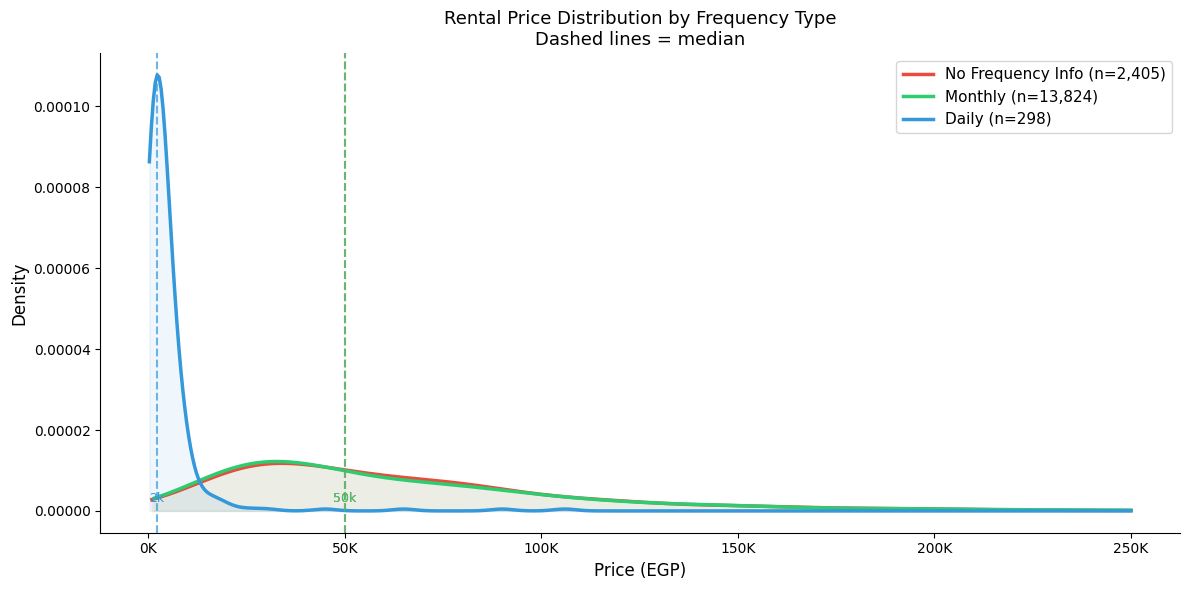

In [119]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

fig, ax = plt.subplots(figsize=(12, 6))

# ── Segment your three groups ─────────────────────────────────
no_freq    = no_rental_frequency['price'].dropna()
monthly    = df[df['rental frequency'] == 'monthly']['price'].dropna()
daily      = df[df['rental frequency'] == 'daily']['price'].dropna()

# ── Optional: clip extreme outliers for cleaner KDE ──────────
cap = df[df['sale_or_rent'] == 'rent']['price'].quantile(0.98)
no_freq = no_freq[no_freq <= cap]
monthly = monthly[monthly <= cap]
daily   = daily[daily <= cap]

# ── Plot KDE for each group ───────────────────────────────────
groups = [
    (no_freq, 'No Frequency Info', '#e74c3c'),
    (monthly, 'Monthly',           '#2ecc71'),
    (daily,   'Daily',             '#3498db'),
]

for data, label, color in groups:
    kde = gaussian_kde(data, bw_method=0.3)
    x = np.linspace(data.min(), cap, 500)
    ax.plot(x, kde(x), label=f'{label} (n={len(data):,})', 
            color=color, linewidth=2.5)
    ax.fill_between(x, kde(x), alpha=0.08, color=color)

# ── Add median vertical lines ─────────────────────────────────
for data, label, color in groups:
    ax.axvline(data.median(), color=color, linestyle='--', 
               linewidth=1.5, alpha=0.7)
    ax.text(data.median(), ax.get_ylim()[1] * 0.02, 
            f'{data.median()/1000:.0f}k', 
            color=color, fontsize=9, ha='center')

# ── Formatting ────────────────────────────────────────────────
ax.set_xlabel('Price (EGP)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Rental Price Distribution by Frequency Type\n'
             'Dashed lines = median', fontsize=13)
ax.legend(fontsize=11)
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x/1_000:.0f}K')
)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
# plt.savefig('rental_frequency_kde.png', dpi=150)
plt.show()

**The price distribution of unkonwn frequency is consisten with the monthly rentals, so I could impute them as monthly.**

In [120]:
no_rental_frequency['district'].value_counts()

district
New Cairo             1780
Madinaty               236
Katameya               107
Maadi                   99
Shorouk City            64
Zahraa Al Maadi         45
Nasr City               32
Al Manial               14
New Capital City        14
Nozha                   13
Zamalek                 13
Mostakbal City           8
Sheraton                 6
Mokattam                 5
New Heliopolis           4
Hadayeq El Zeitoun       4
Heliopolis               2
El Fostat                2
Downtown Cairo           2
Shubra                   1
Helwan                   1
Name: count, dtype: Int64

In [96]:
no_rental_frequency['property_type'].value_counts()

property_type
apartments    2001
villas         430
Name: count, dtype: Int64

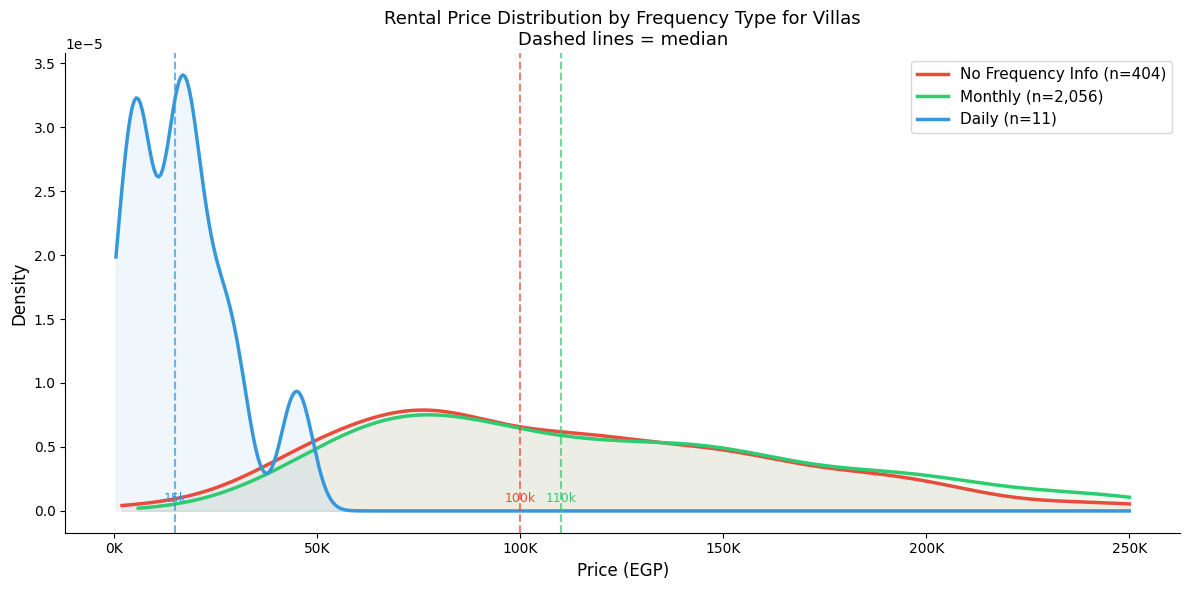

In [121]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

fig, ax = plt.subplots(figsize=(12, 6))

# ── Segment your three groups ─────────────────────────────────
no_freq    = no_rental_frequency[no_rental_frequency['property_type'] == 'villas']['price'].dropna()
monthly    = df[(df['rental frequency'] == 'monthly') & (df['property_type'] == 'villas')]['price'].dropna()
daily      = df[(df['rental frequency'] == 'daily') & (df['property_type'] == 'villas')]['price'].dropna()

# ── Optional: clip extreme outliers for cleaner KDE ──────────
cap = df[df['sale_or_rent'] == 'rent']['price'].quantile(0.98)
no_freq = no_freq[no_freq <= cap]
monthly = monthly[monthly <= cap]
daily   = daily[daily <= cap]

# ── Plot KDE for each group ───────────────────────────────────
groups = [
    (no_freq, 'No Frequency Info', '#e74c3c'),
    (monthly, 'Monthly',           '#2ecc71'),
    (daily,   'Daily',             '#3498db'),
]

for data, label, color in groups:
    kde = gaussian_kde(data, bw_method=0.3)
    x = np.linspace(data.min(), cap, 500)
    ax.plot(x, kde(x), label=f'{label} (n={len(data):,})', 
            color=color, linewidth=2.5)
    ax.fill_between(x, kde(x), alpha=0.08, color=color)

# ── Add median vertical lines ─────────────────────────────────
for data, label, color in groups:
    ax.axvline(data.median(), color=color, linestyle='--', 
               linewidth=1.5, alpha=0.7)
    ax.text(data.median(), ax.get_ylim()[1] * 0.02, 
            f'{data.median()/1000:.0f}k', 
            color=color, fontsize=9, ha='center')

# ── Formatting ────────────────────────────────────────────────
ax.set_xlabel('Price (EGP)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Rental Price Distribution by Frequency Type for Villas\n'
             'Dashed lines = median', fontsize=13)
ax.legend(fontsize=11)
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x/1_000:.0f}K')
)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
# plt.savefig('rental_frequency_kde.png', dpi=150)
plt.show()

### The price distribution of unknown-frequency listings is consistent with monthly rentals, so we impute them as monthly.

In [122]:
for index,row in no_rental_frequency.iterrows():
    df.loc[index, 'rental frequency'] = 'monthly'

In [123]:

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 76520 entries, 0 to 76710
Data columns (total 39 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   title                        76518 non-null  string        
 1   city                         76520 non-null  string        
 2   district                     76520 non-null  string        
 3   area                         69955 non-null  string        
 4   neighborhood                 40625 non-null  string        
 5   property_type                76520 non-null  string        
 6   sale_or_rent                 76520 non-null  string        
 7   price                        76520 non-null  Int64         
 8   seller_name                  76520 non-null  string        
 9   property_subtype             76520 non-null  string        
 10  bedrooms                     76520 non-null  string        
 11  bathrooms                    76520 non-null  s

In [124]:
deposit_and_insurance= df[(~df['deposit'].isnull()) & (~ df['insurance'].isnull())]

In [ ]:
deposit_and_insurance['sale_or_rent'].value_counts()

sale_or_rent
rent    2520
Name: count, dtype: Int64

In [ ]:
deposit_and_insurance['district'].value_counts()

In [125]:
df['deposit'] = df['deposit'].str.replace(',', '').replace('nan',pd.NA).astype('Int64')
df['insurance'] = df['insurance'].str.replace(',','').replace('nan', pd.NA).astype('Int64')

## 7.Investigate: Delivery Date

In [126]:
df['delivery date'].value_counts()

delivery date
nan                75476
2027                 449
2026                 214
2028                 156
2029                  93
2029.0                45
soon                  23
2030                  19
within 6 months       13
2027.0                 8
2025                   7
2028.0                 4
2030.0                 4
2026.0                 3
7.0                    2
7                      2
14                     1
13                     1
Name: count, dtype: Int64

In [127]:
off_plan_values = ['2027', '2028', '2029', '2030', '2027.0', '2028.0']
df['is_off_plan'] = df['delivery date'].isin(off_plan_values)

In [128]:
df.drop(columns=['delivery date'], inplace = True)

In [132]:
columns = ['bedrooms', 'bathrooms','purpose', 'ownership']
for column in columns:
    print(f'Unique values for {column} are:\n {df[column].value_counts()}')


Unique values for bedrooms are:
 bedrooms
3      20933
3.0    17972
4       9996
2.0     9889
2       6039
5       4048
1.0     2490
4.0     2056
6       1220
1        842
7        443
5.0      190
8        151
10+      103
6.0       58
9         43
10        39
7.0        5
9.0        2
8.0        1
Name: count, dtype: Int64
Unique values for bathrooms are:
 bathrooms
3      16233
2.0    13731
3.0    11918
4      10013
2       8794
1.0     4997
5       3959
1       2526
4.0     1820
6       1330
7        612
8        184
5.0      153
10+      106
9         54
10        46
6.0       36
7.0        7
8.0        1
Name: count, dtype: Int64
Unique values for purpose are:
 purpose
for sale    59620
for rent    16900
Name: count, dtype: Int64
Unique values for ownership are:
 ownership
resale     27415
primary    21229
Name: count, dtype: Int64


In [138]:

def clean_room_column(series: pd.Series) -> pd.Series:
    """
    Cleans bedroom/bathroom columns by:
    - Stripping whitespace
    - Replacing '10+' with 10
    - Casting to float first (handles mixed int/float strings), then to nullable Int64
    - Clips values to [1, 10]
    """
    cleaned = (
        series
        .astype(str)
        .str.strip()
        .str.replace(r'^\s*10\+\s*$', '10', regex=True)  # normalize 10+
        .pipe(pd.to_numeric, errors='coerce')             # "3.0" → 3.0, NaN stays NaN
        .clip(lower=1, upper=10)                           # clip outliers
        .astype('Int64')                                   # nullable integer, preserves NaN
    )

    n_nulls = cleaned.isna().sum()
    n_clipped = (cleaned == 10).sum()
    print(f"nulls: {n_nulls} | values capped at 10: {n_clipped}")
    
    return cleaned

In [ ]:
df['bedrooms']  = clean_room_column(df['bedrooms'])


nulls: 0 | values capped at 10: 142


In [143]:
df['bathrooms']  = clean_room_column(df['bathrooms'])

nulls: 0 | values capped at 10: 152


In [142]:
df['bedrooms'].value_counts()

bedrooms
3     38905
2     15928
4     12052
5      4238
1      3332
6      1278
7       448
8       152
10      142
9        45
Name: count, dtype: Int64

In [144]:
df['bathrooms'].value_counts()

bathrooms
3     28151
2     22525
4     11833
1      7523
5      4112
6      1366
7       619
8       185
10      152
9        54
Name: count, dtype: Int64

In [145]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 76520 entries, 0 to 76710
Data columns (total 39 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   title                        76518 non-null  string        
 1   city                         76520 non-null  string        
 2   district                     76520 non-null  string        
 3   area                         69955 non-null  string        
 4   neighborhood                 40625 non-null  string        
 5   property_type                76520 non-null  string        
 6   sale_or_rent                 76520 non-null  string        
 7   price                        76520 non-null  Int64         
 8   seller_name                  76520 non-null  string        
 9   property_subtype             76520 non-null  string        
 10  bedrooms                     76520 non-null  Int64         
 11  bathrooms                    76520 non-null  I

## Lastly: save the cleaned dataset 
**I will save it into parquet to preserve the datatypes**

In [151]:
df.to_parquet(config['data_source']['file_paths']['cleaned_dataset'], index=False)

In [132]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 70344 entries, 0 to 70533
Data columns (total 39 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   title                        70342 non-null  string        
 1   city                         70344 non-null  string        
 2   district                     70344 non-null  string        
 3   area                         63779 non-null  string        
 4   neighborhood                 40625 non-null  string        
 5   property_type                70344 non-null  string        
 6   sale_or_rent                 70344 non-null  string        
 7   price                        70344 non-null  Int64         
 8   seller_name                  70344 non-null  string        
 9   property_subtype             70344 non-null  string        
 10  bedrooms                     70344 non-null  string        
 11  bathrooms                    70344 non-null  s

## Cleaning Decisions Summary

| Column | Action | Reason |
|---|---|---|
| compound | Dropped | 3 non-null values, redundant with neighborhood |
| delivery date | Dropped → derived `is_off_plan` boolean | 69k nulls but non-null values indicate off-plan properties, real price signal |
| delivery term | Imputed then excluded from model | 71% missing, retained for EDA only |
| level | Imputed in 3 layers → level_clean | Went from 6k to 50k+ using subtype logic + regex |
| rental frequency | Imputed nulls as monthly | KDE confirmed distribution matches monthly |
| deposit / insurance | Kept for EDA, excluded from model | 79% missing, concentrated in New Cairo/Madinaty |
| price type | Dropped | Redundant |
| bedrooms & bathroom| fixed some data inconssitenty | To assign the proper datatype| 

## Key Takeaways

- The dataset is heavily bilingual (Arabic/English) and sometimes mixed within the same listing.
  Every extraction and imputation step had to handle both languages separately.

- Missing data is not random. Most null-heavy columns (delivery term, deposit, insurance, level)
  are missing because certain listing types or districts simply don't include that information —
  not because of scraping errors. This means dropping nulls blindly would introduce bias.

- New Cairo dominates the dataset across almost every segment. Any model trained on this data
  should be evaluated per district, not just overall, to avoid New Cairo skewing the results.

- Imputation decisions were evidence-based, not assumption-based. Every imputation 
  (level, rental frequency, delivery term) was backed by either distribution analysis, 
  domain logic, or regex extraction from titles — not filling with means or modes blindly.

- Several columns were kept for EDA and the future RAG chatbot even after being excluded 
  from the model feature matrix. The dataset is a knowledge base about Cairo rental market 
  behavior, not just a modeling input.

- The title column was the single most valuable source for imputation across the entire 
  notebook — level, delivery term, finishing, and rental frequency all drew from it.